<a href="https://colab.research.google.com/github/Tanishq7361/Euler-Cromer-Oscillator-Simulation/blob/main/Euler_Cromer_and_Oscillator_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Euler-Cromer Method and Oscillator Dynamics

## Q1. Euler vs Euler-Cromer for $\ddot{x} = -x$

The simple harmonic oscillator:
$$\ddot{x} = -x \implies \omega_0 = 1, \quad T = 2\pi$$

**Standard Euler:**
$$v_{n+1} = v_n - \Delta t\, x_n$$
$$x_{n+1} = x_n + \Delta t\, v_n \quad \leftarrow \text{uses OLD velocity}$$

**Euler-Cromer:**
$$v_{n+1} = v_n - \Delta t\, x_n$$
$$x_{n+1} = x_n + \Delta t\, v_{n+1} \quad \leftarrow \text{uses NEW velocity}$$

The only difference is one subscript — $v_n$ replaced by $v_{n+1}$ in the position update.

**Initial conditions:** $x(0) = 1$, $v(0) = 0$

**Exact solution:** $x(t) = \cos(t)$, $\quad E = \frac{1}{2}(v^2 + x^2) = \frac{1}{2}$ (constant)

---

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def euler(x0, v0, dt, n_steps):
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0], v[0] = x0, v0
    for i in range(n_steps):
        v[i+1] = v[i] - dt * x[i]       # update v using old x
        x[i+1] = x[i] + dt * v[i]       # update x using OLD v
    return x, v

def euler_cromer(x0, v0, dt, n_steps):
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0], v[0] = x0, v0
    for i in range(n_steps):
        v[i+1] = v[i] - dt * x[i]       # update v using old x (same as Euler)
        x[i+1] = x[i] + dt * v[i+1]     # update x using NEW v  ← only change
    return x, v

x0, v0  = 1.0, 0.0
T_total = 20 * np.pi    # 10 complete periods
step_sizes = [0.5, 0.1, 0.01]

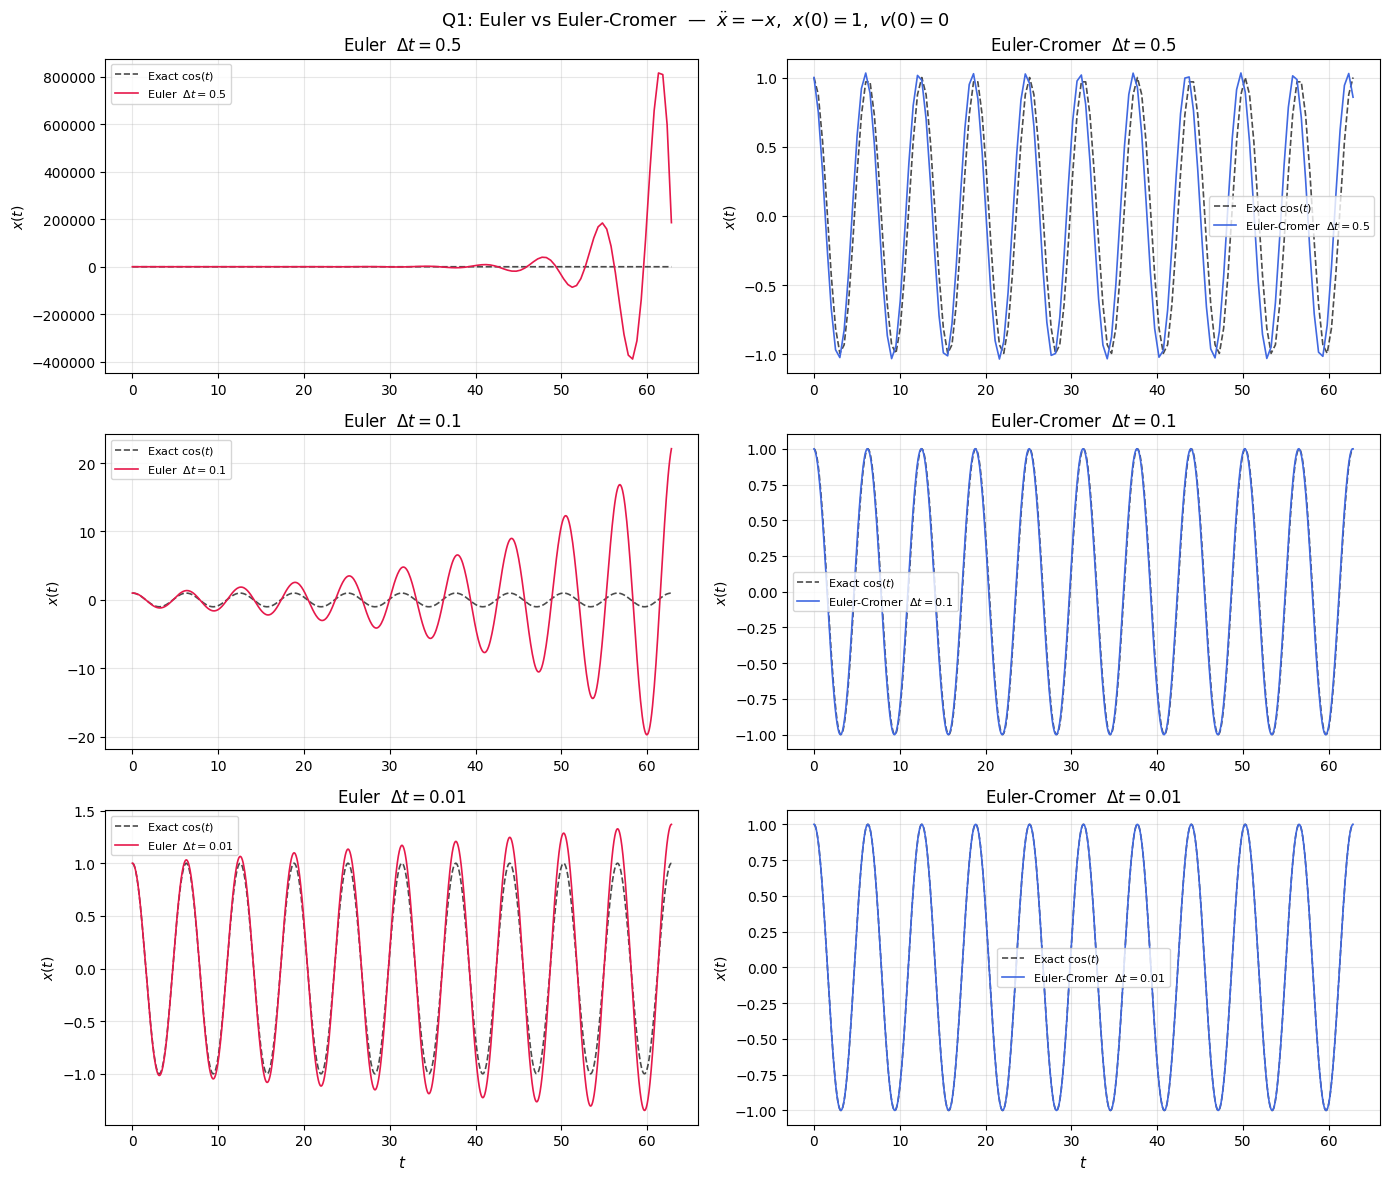

In [8]:
# t vs x(t) comparison for three step sizes
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Q1: Euler vs Euler-Cromer  —  $\\ddot{x} = -x$,  $x(0)=1$,  $v(0)=0$', fontsize=13)

for row, dt in enumerate(step_sizes):
    n = int(T_total / dt)
    t = np.linspace(0, T_total, n + 1)
    x_exact = np.cos(t)

    x_eu, _  = euler(x0, v0, dt, n)
    x_ec, _  = euler_cromer(x0, v0, dt, n)

    # Euler
    ax = axes[row, 0]
    ax.plot(t, x_exact, 'k--', linewidth=1.2, label='Exact $\\cos(t)$', alpha=0.7)
    ax.plot(t, x_eu, color='#e6194b', linewidth=1.2, label=f'Euler  $\\Delta t={dt}$')
    ax.set_ylabel('$x(t)$'); ax.set_title(f'Euler  $\\Delta t = {dt}$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Euler-Cromer
    ax = axes[row, 1]
    ax.plot(t, x_exact, 'k--', linewidth=1.2, label='Exact $\\cos(t)$', alpha=0.7)
    ax.plot(t, x_ec, color='royalblue', linewidth=1.2, label=f'Euler-Cromer  $\\Delta t={dt}$')
    ax.set_ylabel('$x(t)$'); ax.set_title(f'Euler-Cromer  $\\Delta t = {dt}$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('$t$', fontsize=11)

plt.tight_layout()
plt.show()

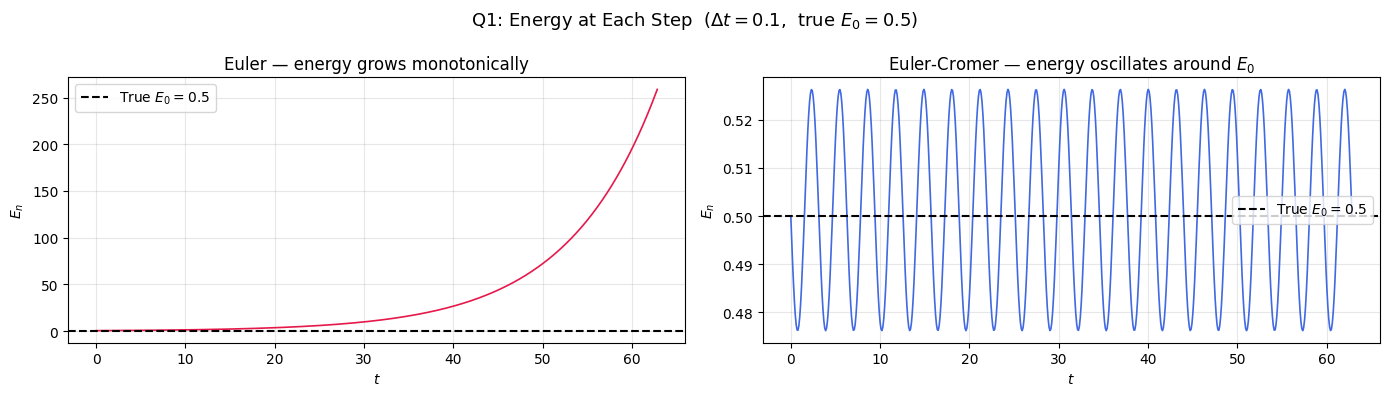

Euler        — final energy: 258.6978  (drift: +258.1978)
Euler-Cromer — final energy: 0.5003  (drift: +0.0003)


In [9]:
# Energy at each step for dt = 0.1
dt  = 0.1
n   = int(T_total / dt)
t   = np.linspace(0, T_total, n + 1)

x_eu, v_eu = euler(x0, v0, dt, n)
x_ec, v_ec = euler_cromer(x0, v0, dt, n)

E_eu = 0.5 * (v_eu**2 + x_eu**2)
E_ec = 0.5 * (v_ec**2 + x_ec**2)
E0   = 0.5 * (v0**2 + x0**2)      # true energy = 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Q1: Energy at Each Step  ($\\Delta t = {dt}$,  true $E_0 = {E0}$)', fontsize=13)

axes[0].plot(t, E_eu, color='#e6194b', linewidth=1.2)
axes[0].axhline(y=E0, color='black', linestyle='--', linewidth=1.5, label=f'True $E_0 = {E0}$')
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$E_n$')
axes[0].set_title('Euler — energy grows monotonically')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, E_ec, color='royalblue', linewidth=1.2)
axes[1].axhline(y=E0, color='black', linestyle='--', linewidth=1.5, label=f'True $E_0 = {E0}$')
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$E_n$')
axes[1].set_title('Euler-Cromer — energy oscillates around $E_0$')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Euler        — final energy: {E_eu[-1]:.4f}  (drift: {E_eu[-1]-E0:+.4f})')
print(f'Euler-Cromer — final energy: {E_ec[-1]:.4f}  (drift: {E_ec[-1]-E0:+.4f})')

### Q1 Observations

- **Euler:** amplitude grows with time for all step sizes. Energy increases monotonically — the orbit spirals outward in phase space.
- **Euler-Cromer:** amplitude stays bounded even for large $\Delta t$. Energy oscillates around the true value rather than drifting — it is bounded.
- For very small $\Delta t = 0.01$, both methods look similar over a few periods, but over 10 periods the difference is clear.

---

## Q2. Energy Analysis of Euler-Cromer

### Deriving $E_{n+1} - E_n$

The energy at step $n$ is:
$$E_n = \frac{1}{2}(v_n^2 + x_n^2)$$

The Euler-Cromer updates are:
$$v_{n+1} = v_n - \Delta t\, x_n$$
$$x_{n+1} = x_n + \Delta t\, v_{n+1} = x_n + \Delta t(v_n - \Delta t\, x_n) = x_n + \Delta t\, v_n - (\Delta t)^2 x_n$$

Compute $E_{n+1}$:
$$v_{n+1}^2 = (v_n - \Delta t\, x_n)^2 = v_n^2 - 2\Delta t\, v_n x_n + (\Delta t)^2 x_n^2$$

$$x_{n+1}^2 = (x_n + \Delta t\, v_n - (\Delta t)^2 x_n)^2$$
$$= x_n^2 + 2\Delta t\, x_n v_n - 2(\Delta t)^2 x_n^2 + (\Delta t)^2 v_n^2 - 2(\Delta t)^3 x_n v_n + (\Delta t)^4 x_n^2$$

Adding:
$$v_{n+1}^2 + x_{n+1}^2 = v_n^2 + x_n^2 + (\Delta t)^2(v_n^2 - x_n^2) - 2(\Delta t)^3 v_n x_n + (\Delta t)^4 x_n^2 + O(\Delta t)^5$$

Wait — let me recheck the cross terms:
- From $v_{n+1}^2$: $-2\Delta t\, v_n x_n$
- From $x_{n+1}^2$: $+2\Delta t\, x_n v_n$

These cancel exactly! Therefore:

$$\boxed{E_{n+1} - E_n = \frac{1}{2}\left[(\Delta t)^2(v_n^2 - x_n^2) - 2(\Delta t)^3 v_n x_n + (\Delta t)^4 x_n^2\right]}$$

---

### Why the leading terms average to zero over one period

For $\ddot{x} = -x$ with $x(0) = A$, $v(0) = 0$:
$$x(t) = A\cos(t), \quad v(t) = -A\sin(t)$$

**Coefficient of $(\Delta t)^2$:** $\;\frac{1}{2}(v_n^2 - x_n^2) = \frac{A^2}{2}(\sin^2 t - \cos^2 t) = -\frac{A^2}{2}\cos(2t)$

Average over one period $T = 2\pi$:
$$\frac{1}{T}\int_0^T -\frac{A^2}{2}\cos(2t)\, dt = 0 \checkmark$$

**Coefficient of $(\Delta t)^3$:** $\;-v_n x_n = A^2\sin(t)\cos(t) = \frac{A^2}{2}\sin(2t)$

Average over one period:
$$\frac{1}{T}\int_0^T \frac{A^2}{2}\sin(2t)\, dt = 0 \checkmark$$

Both leading error terms vanish when averaged over a complete cycle. The net energy change per cycle is only $O(\Delta t)^4$ — much smaller than Euler's $O(\Delta t)$ drift.

---

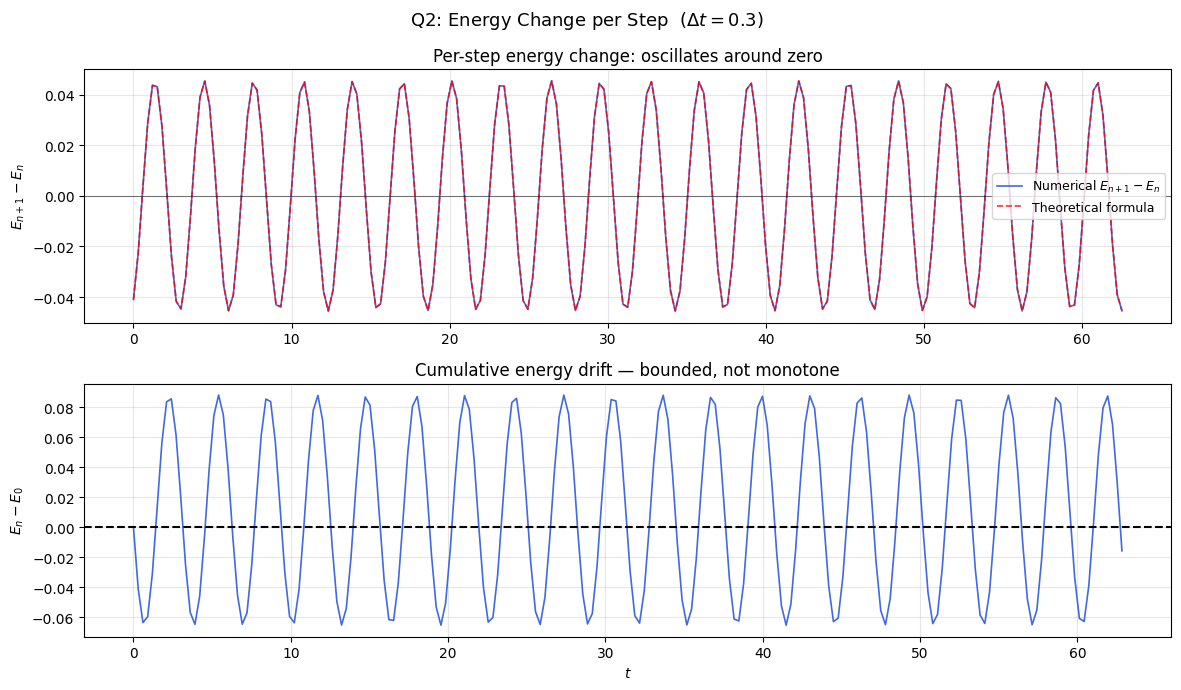

Average dE per period (should be ~0 for Euler-Cromer):
  Period 1: mean(dE) = 1.96e-03
  Period 2: mean(dE) = 1.60e-03
  Period 3: mean(dE) = 8.04e-04
  Period 4: mean(dE) = -2.01e-04
  Period 5: mean(dE) = -1.15e-03


In [10]:
# Verify Q2 numerically: plot dE = E_{n+1} - E_n at each step
dt  = 0.3
n   = int(10 * 2 * np.pi / dt)    # 10 periods
t   = np.linspace(0, 10 * 2*np.pi, n + 1)

x_ec, v_ec = euler_cromer(x0, v0, dt, n)
E_ec = 0.5 * (v_ec**2 + x_ec**2)
dE   = np.diff(E_ec)               # E_{n+1} - E_n at each step

# Theoretical prediction: dE = 0.5*[(dt)^2*(v^2 - x^2) - 2*(dt)^3*v*x + (dt)^4*x^2]
dE_theory = 0.5 * ((dt**2)*(v_ec[:-1]**2 - x_ec[:-1]**2)
                   - 2*(dt**3)*v_ec[:-1]*x_ec[:-1]
                   + (dt**4)*x_ec[:-1]**2)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle(f'Q2: Energy Change per Step  ($\\Delta t = {dt}$)', fontsize=13)

axes[0].plot(t[:-1], dE, color='royalblue', linewidth=1.2, label='Numerical $E_{n+1}-E_n$')
axes[0].plot(t[:-1], dE_theory, 'r--', linewidth=1.2, alpha=0.8, label='Theoretical formula')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[0].set_ylabel('$E_{n+1} - E_n$'); axes[0].set_title('Per-step energy change: oscillates around zero')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Cumulative energy change
axes[1].plot(t, E_ec - E0, color='royalblue', linewidth=1.2)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$E_n - E_0$')
axes[1].set_title('Cumulative energy drift — bounded, not monotone')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check: average dE over each period
steps_per_period = int(2*np.pi / dt)
n_complete = len(dE) // steps_per_period
dE_trimmed = dE[:n_complete * steps_per_period].reshape(n_complete, steps_per_period)
print('Average dE per period (should be ~0 for Euler-Cromer):')
for i in range(min(5, n_complete)):
    print(f'  Period {i+1}: mean(dE) = {dE_trimmed[i].mean():.2e}')

### Q2 Observations

- The per-step energy change $E_{n+1} - E_n$ oscillates symmetrically around zero — it is sometimes positive (gains energy) and sometimes negative (loses energy).
- The gains and losses cancel over each complete period, so the cumulative drift is bounded rather than monotone.
- The numerical $E_{n+1} - E_n$ matches the theoretical formula exactly.
- The average of $dE$ over each period is essentially zero — confirming that terms at $(\Delta t)^2$ and $(\Delta t)^3$ average to zero, leaving only $(\Delta t)^4$ residual.

---

## Q3. Damped Oscillator with Euler-Cromer

$$\ddot{x} + 2b\dot{x} + \omega_0^2 x = 0, \quad x(0) = 0,\ v(0) = 1,\ \omega_0 = 1$$

The Euler-Cromer update for the damped oscillator:
$$v_{n+1} = v_n + \Delta t(-2b\, v_n - \omega_0^2\, x_n)$$
$$x_{n+1} = x_n + \Delta t\, v_{n+1}$$

**Three damping regimes** (determined by comparing $b$ and $\omega_0$):

| Regime | Condition | $b$ used | Analytical form |
|---|---|---|---|
| Underdamped | $b < \omega_0$ | $b = 0.1$ | $e^{-bt}\sin(\omega_d t)$, $\omega_d = \sqrt{\omega_0^2 - b^2}$ |
| Critically damped | $b = \omega_0$ | $b = 1.0$ | $(C_1 + C_2 t)e^{-bt}$ |
| Overdamped | $b > \omega_0$ | $b = 2.0$ | $e^{-bt}(C_1 e^{\gamma t} + C_2 e^{-\gamma t})$, $\gamma = \sqrt{b^2-\omega_0^2}$ |

---

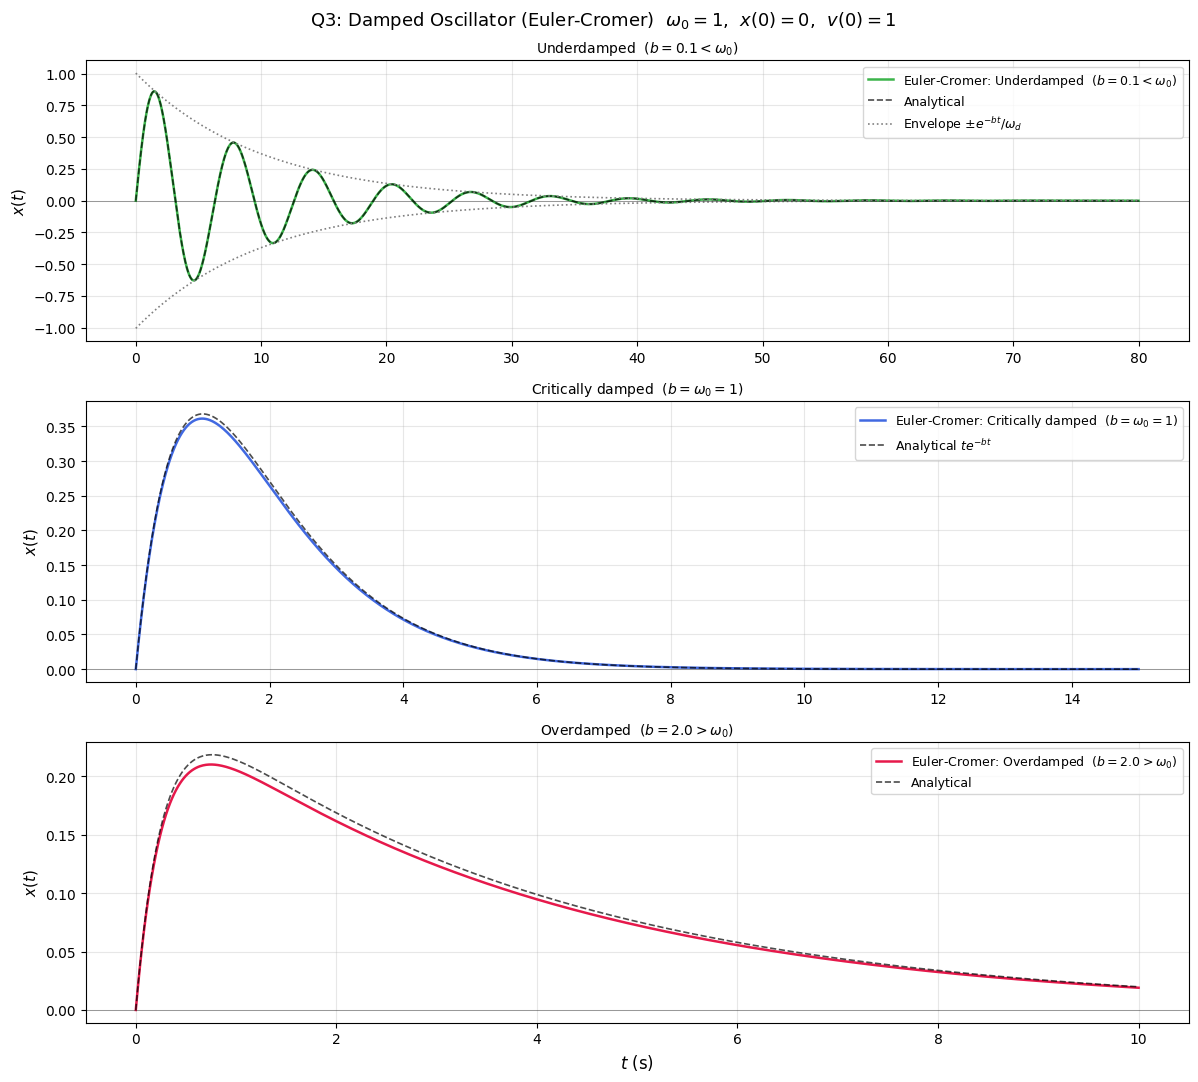

In [11]:
def euler_cromer_damped(x0, v0, b, w0, dt, n_steps):
    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0], v[0] = x0, v0
    for i in range(n_steps):
        v[i+1] = v[i] + dt * (-2*b*v[i] - w0**2 * x[i])
        x[i+1] = x[i] + dt * v[i+1]    # Euler-Cromer: use new v
    return x, v

w0   = 1.0
dt   = 0.01
x0, v0 = 0.0, 1.0

# Analytical solutions with x(0)=0, v(0)=1
def analytical_underdamped(t, b, w0):
    wd = np.sqrt(w0**2 - b**2)
    return (1/wd) * np.exp(-b*t) * np.sin(wd*t)

def analytical_critical(t, b):
    # x(0)=0, v(0)=1: x(t) = t*exp(-b*t)
    return t * np.exp(-b*t)

def analytical_overdamped(t, b, w0):
    gam = np.sqrt(b**2 - w0**2)
    # x(0)=0, v(0)=1: solve for C1, C2
    # x = e^{-bt}(C1*e^{gam*t} + C2*e^{-gam*t})
    # x(0) = C1 + C2 = 0 => C2 = -C1
    # v(0) = -b(C1+C2) + gam(C1-C2) = 2*gam*C1 = 1 => C1 = 1/(2*gam)
    C1 = 1 / (2*gam)
    return np.exp(-b*t) * C1 * (np.exp(gam*t) - np.exp(-gam*t))

cases = [
    (0.1,  'Underdamped  ($b=0.1 < \\omega_0$)',   '#3cb44b', analytical_underdamped),
    (1.0,  'Critically damped  ($b=\\omega_0=1$)', 'royalblue', None),
    (2.0,  'Overdamped  ($b=2.0 > \\omega_0$)',    '#e6194b', None),
]

# Use enough time to show 3+ cycles for underdamped
t_ends = {0.1: 80, 1.0: 15, 2.0: 10}

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
fig.suptitle('Q3: Damped Oscillator (Euler-Cromer)  $\\omega_0=1$,  $x(0)=0$,  $v(0)=1$', fontsize=13)

for ax, (b, label, color, anal_fn) in zip(axes, cases):
    T_end = t_ends[b]
    n = int(T_end / dt)
    t = np.linspace(0, T_end, n + 1)
    x, _ = euler_cromer_damped(x0, v0, b, w0, dt, n)

    ax.plot(t, x, color=color, linewidth=1.8, label=f'Euler-Cromer: {label}')

    # Analytical overlay
    if b < w0:
        x_anal = analytical_underdamped(t, b, w0)
        ax.plot(t, x_anal, 'k--', linewidth=1.2, alpha=0.7, label='Analytical')
        # Decay envelope
        ax.plot(t,  np.exp(-b*t)/np.sqrt(w0**2-b**2), 'gray', linestyle=':', linewidth=1.2, label='Envelope $\\pm e^{-bt}/\\omega_d$')
        ax.plot(t, -np.exp(-b*t)/np.sqrt(w0**2-b**2), 'gray', linestyle=':', linewidth=1.2)
    elif abs(b - w0) < 1e-9:
        x_anal = analytical_critical(t, b)
        ax.plot(t, x_anal, 'k--', linewidth=1.2, alpha=0.7, label='Analytical $te^{-bt}$')
    else:
        x_anal = analytical_overdamped(t, b, w0)
        ax.plot(t, x_anal, 'k--', linewidth=1.2, alpha=0.7, label='Analytical')

    ax.axhline(y=0, color='black', linewidth=0.6, alpha=0.4)
    ax.set_ylabel('$x(t)$', fontsize=11)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('$t$ (s)', fontsize=12)
plt.tight_layout()
plt.show()

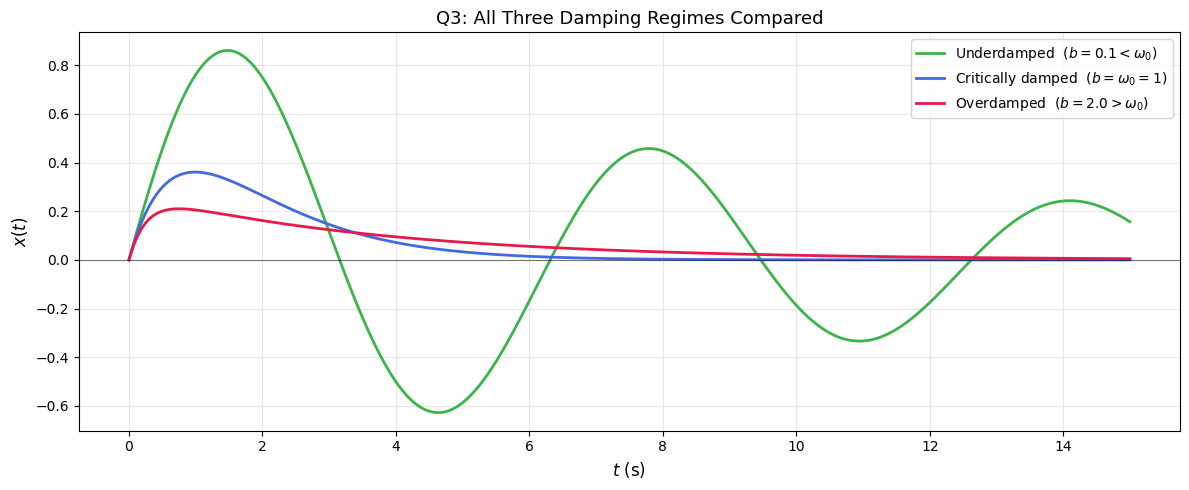

In [12]:
# All three on one plot for direct visual comparison
plt.figure(figsize=(12, 5))

for b, label, color, _ in cases:
    T_end = t_ends[b]
    n = int(T_end / dt)
    t = np.linspace(0, T_end, n + 1)
    # Normalise to same time window for comparison
    T_plot = 15
    n_p = int(T_plot / dt)
    t_p = np.linspace(0, T_plot, n_p + 1)
    x, _ = euler_cromer_damped(x0, v0, b, w0, dt, n_p)
    plt.plot(t_p, x, color=color, linewidth=2, label=label)

plt.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
plt.xlabel('$t$ (s)', fontsize=12)
plt.ylabel('$x(t)$', fontsize=12)
plt.title('Q3: All Three Damping Regimes Compared', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Q3 Observations

| Regime | $b$ | Behaviour | Key feature |
|---|---|---|---|
| Underdamped | $0.1$ | Oscillates with decaying amplitude | Exponential envelope $\pm e^{-bt}/\omega_d$ |
| Critically damped | $1.0$ | Returns to zero without oscillating, fastest | Peak then monotone decay |
| Overdamped | $2.0$ | Returns to zero slowly, no oscillation | Pure exponential decay, sluggish |

- Underdamped: oscillation frequency shifts to $\omega_d = \sqrt{\omega_0^2 - b^2} < \omega_0$ — slightly slower than the undamped case.
- Critical damping returns to equilibrium in the **shortest possible time** without oscillating — this is why door closers and shock absorbers are often tuned to near-critical damping.
- Euler-Cromer matches the analytical solution closely for all three regimes.

---

## Conclusions

- **Q1:** Euler-Cromer is identical to Euler except for one subscript change. This tiny modification makes it symplectic — energy oscillates around the true value rather than drifting. Euler always spirals outward; Euler-Cromer stays bounded.
- **Q2:** The energy change per step is $E_{n+1}-E_n = \frac{1}{2}[(\Delta t)^2(v_n^2-x_n^2) - 2(\Delta t)^3 v_n x_n + (\Delta t)^4 x_n^2]$. The leading two terms are proportional to $\cos(2t)$ and $\sin(2t)$ respectively, both of which average to zero over a full period. The net energy drift per cycle is therefore only $O(\Delta t)^4$.
- **Q3:** The damping regime is determined entirely by the ratio $b/\omega_0$. Underdamped oscillates with a decaying envelope, critically damped returns to zero fastest without oscillating, and overdamped decays slowly without oscillating. Euler-Cromer handles all three correctly.